In [2]:
from TimeTagger import *
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import asyncio
import numpy as np
from ipywidgets import Button
import plotly.graph_objs as go
import pprint

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 20,
         "xtick.direction": "in",
         "xtick.major.pad": 8,
         "xtick.top": True,
         "ytick.labelsize": 20,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 20,
         "axes.labelpad": 10,
         "axes.grid": True
    }
)

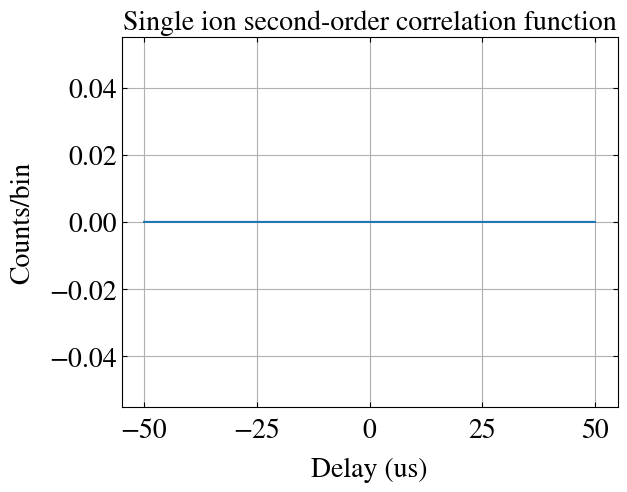

Date 2023-12-27, Time 16-8


True

In [4]:
# Define channels
trigger_channel = 2
PMT_channel1 = 1
PMT_channel2 = 3

tagger = createTimeTagger()

# Measure correlation between the filtered PMT channels to calculate the g(2) function
binwidth = 50 * 1e3  # Adjust binwidth as needed
n_bins = 2000   # Adjust number of bins as needed
DELAY = 600 * 1e3 # The gate time is 1us

open_gate = DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=480 * 1e3)
open_gate_channel = open_gate.getChannel()
close_gate = DelayedChannel(tagger=tagger, input_channel=open_gate_channel, delay=DELAY)
close_gate_channel = close_gate.getChannel()

gated_PMT_channel1 = GatedChannel(tagger=tagger, input_channel=PMT_channel1, gate_start_channel=open_gate_channel, gate_stop_channel=close_gate_channel)
gated_PMT_channel2 = GatedChannel(tagger=tagger, input_channel=PMT_channel2, gate_start_channel=open_gate_channel, gate_stop_channel=close_gate_channel)

# Start the correlation measurement
corr = Correlation(tagger=tagger, channel_1=gated_PMT_channel1.getChannel(), channel_2=gated_PMT_channel2.getChannel(), binwidth=binwidth, n_bins=n_bins)
measurement_time = int(0.001 * 3600 * 1e12)  # Adjust measurement time as needed
corr.startFor(measurement_time)
corr.waitUntilFinished()

# Get the correlation data
g2_data = corr.getData()
index = corr.getIndex() / 1e6

np.save('corr_meas.npy', index, g2_data)

# Plot the g(2) function
plt.plot(index, g2_data)
plt.title("Single ion second-order correlation function", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()

# Getting the current date and time
now = datetime.now()

# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute

# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)

np.save('corr.getData_'+formatted_string+'.npy', corr.getData())
np.save('corr.getIndex_'+formatted_string+'.npy', corr.getIndex())

# Free the TimeTagger
freeTimeTagger(tagger)

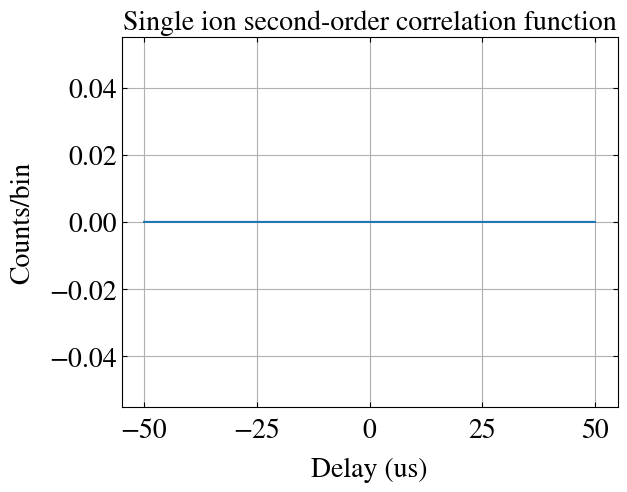

Date 2023-12-27, Time 16-8


True

In [5]:
# Define channels
trigger_channel = 2
PMT_channel1 = 1
PMT_channel2 = 3

tagger = createTimeTagger()

# Measure correlation between the filtered PMT channels to calculate the g(2) function
binwidth = 50 * 1e3  # Adjust binwidth as needed
n_bins = 2000   # Adjust number of bins as needed
DELAY = 600 * 1e3 # The gate time is 1us

open_gate = DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=480 * 1e3)
open_gate_channel = open_gate.getChannel()
close_gate = DelayedChannel(tagger=tagger, input_channel=open_gate_channel, delay=DELAY)
close_gate_channel = close_gate.getChannel()

gated_PMT_channel1 = GatedChannel(tagger=tagger, input_channel=PMT_channel1, gate_start_channel=open_gate_channel, gate_stop_channel=close_gate_channel)
gated_PMT_channel2 = GatedChannel(tagger=tagger, input_channel=PMT_channel2, gate_start_channel=open_gate_channel, gate_stop_channel=close_gate_channel)

# Start the correlation measurement
corr = Correlation(tagger=tagger, channel_1=gated_PMT_channel1.getChannel(), channel_2=gated_PMT_channel2.getChannel(), binwidth=binwidth, n_bins=n_bins)
measurement_time = int(0.001 * 3600 * 1e12)  # Adjust measurement time as needed
corr.startFor(measurement_time)
corr.waitUntilFinished()

# Get the correlation data
g2_data = corr.getData()
index = corr.getIndex() / 1e6

np.save('corr_meas.npy', index, g2_data)

# Plot the g(2) function
plt.plot(index, g2_data)
plt.title("Single ion second-order correlation function", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()

# Getting the current date and time
now = datetime.now()

# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute

# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)

np.save('corr.getData_'+formatted_string+'.npy', corr.getData())
np.save('corr.getIndex_'+formatted_string+'.npy', corr.getIndex())

# Free the TimeTagger
freeTimeTagger(tagger)

In [4]:
path = "D:/Google_Drive/Experimental_Data/Multiplexing/g2_data/"

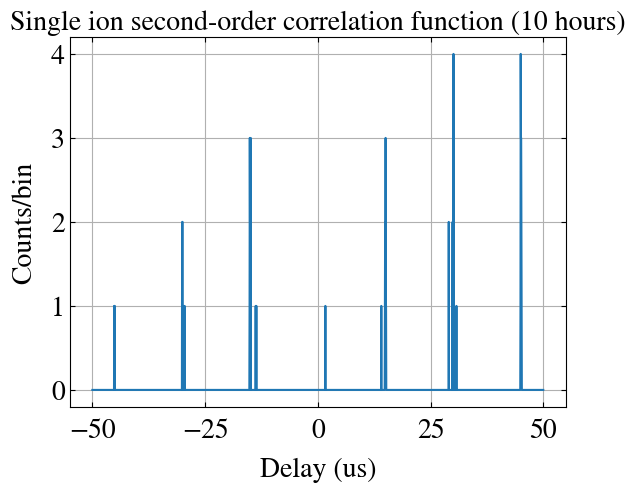

Date 2024-01-03, Time 13-46


In [5]:
index = np.load(path + 'corr.getIndex_Date 2024-01-03, Time 13-41.npy')
data_1 = np.load(path + 'corr.getData_Date 2024-01-03, Time 13-41.npy')
index = index / 1e6
# Plot the g(2) function
plt.plot(index, data_1)
plt.title("Single ion second-order correlation function (10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_10_hours_no_merging.npy', data_1)
# np.save('corr.getIndex_'+formatted_string+'_10_hours_no_merging.npy', index)

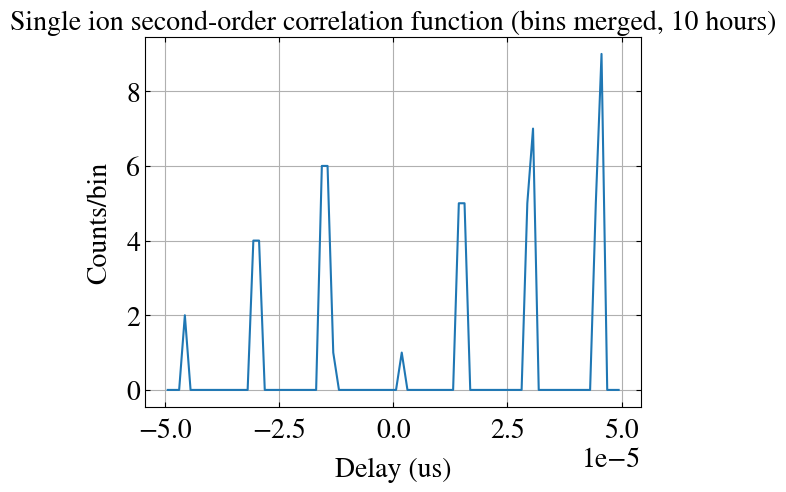

Date 2024-01-03, Time 13-47


In [6]:
sup_binsize = 25
merged_data_sum = []
for i in range(len(data_1)//sup_binsize):
    merged_data_sum.append(np.sum(data_1[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]) / 1e6)

# Plot the g(2) function
plt.plot(merged_index, merged_data_sum)
plt.title("Single ion second-order correlation function (bins merged, 10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_10_hours.npy', merged_data_sum)
# np.save('corr.getIndex_'+formatted_string+'_10_hours.npy', merged_index)

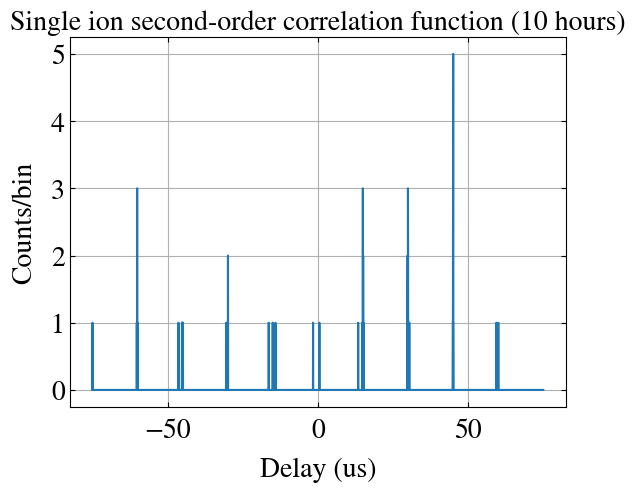

Date 2024-01-03, Time 14-17


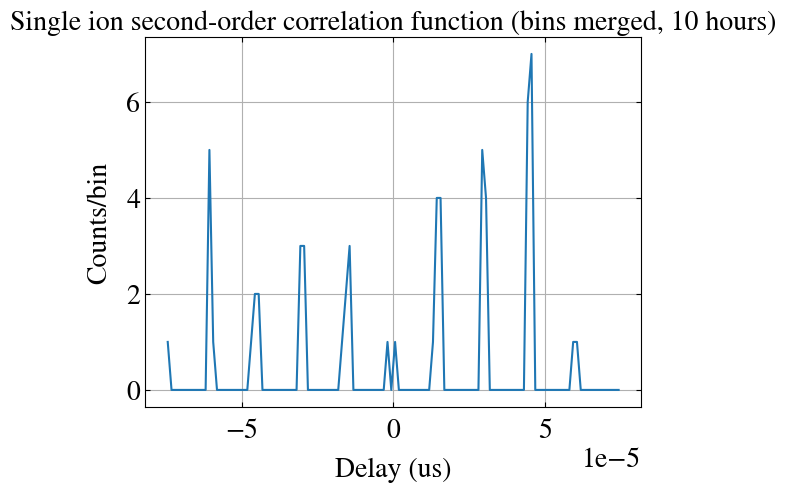

Date 2024-01-03, Time 14-17


In [9]:
path = "D:/Google_Drive/Experimental_Data/Multiplexing/g2_data/"
index = np.load(path + 'corr.getIndex_Date 2024-01-03, Time 14-17.npy')
data_1 = np.load(path + 'corr.getData_Date 2024-01-03, Time 14-17.npy')
index = index / 1e6
# Plot the g(2) function
plt.plot(index, data_1)
plt.title("Single ion second-order correlation function (10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_10_hours_no_merging.npy', data_1)
# np.save('corr.getIndex_'+formatted_string+'_10_hours_no_merging.npy', index)

sup_binsize = 25
merged_data_sum = []
for i in range(len(data_1)//sup_binsize):
    merged_data_sum.append(np.sum(data_1[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]) / 1e6)

# Plot the g(2) function
plt.plot(merged_index, merged_data_sum)
plt.title("Single ion second-order correlation function (bins merged, 10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_10_hours.npy', merged_data_sum)
# np.save('corr.getIndex_'+formatted_string+'_10_hours.npy', merged_index)

In [37]:
path = "D:/Google_Drive/Experimental_Data/Multiplexing/g2_data/"
index = np.load(path + 'corr.getIndex_Date 2024-01-03, Time 14-17.npy')
data_1 = np.load(path + 'corr.getData_Date 2024-01-03, Time 17-41.npy')
data_2 = np.load(path + 'corr.getData_Date 2024-01-03, Time 16-3.npy')
data_3 = np.load(path + 'corr.getData_Date 2024-01-03, Time 16-25.npy')
data_4 = np.load(path + 'corr.getData_Date 2024-01-03, Time 16-44.npy')
data_5 = np.load(path + 'corr.getData_Date 2024-01-03, Time 17-3.npy')
data_6 = np.load(path + 'corr.getData_Date 2024-01-03, Time 17-22.npy')
data_7 = np.load(path + 'corr.getData_Date 2024-01-03, Time 19-55.npy')
data_8 = np.load(path + 'corr.getData_Date 2024-01-04, Time 10-29.npy')
data_9 = np.load(path + 'corr.getData_Date 2024-01-04, Time 10-53.npy')
data_10 = np.load(path + 'corr.getData_Date 2024-01-04, Time 12-25.npy')
data_sum = data_1 + data_2 + data_3 + data_4 + data_5 + data_6 + data_7 + data_8 + data_9 + data_10
index = index / 1e6
# Plot the g(2) function
plt.plot(index, data_sum)
plt.title("Single ion second-order correlation function (10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_10_hours_no_merging.npy', data_1)
# np.save('corr.getIndex_'+formatted_string+'_10_hours_no_merging.npy', index)

sup_binsize = 25
merged_data_sum = []
for i in range(len(data_sum)//sup_binsize):
    merged_data_sum.append(np.sum(data_sum[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]) / 1e6)

# Plot the g(2) function
plt.plot(merged_index, merged_data_sum)
plt.title("Single ion second-order correlation function (bins merged, 10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_10_hours.npy', merged_data_sum)
# np.save('corr.getIndex_'+formatted_string+'_10_hours.npy', merged_index)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Google_Drive/Experimental_Data/Multiplexing/g2_data/corr.getData_Date 2024-01-04, Time 12-25.npy'

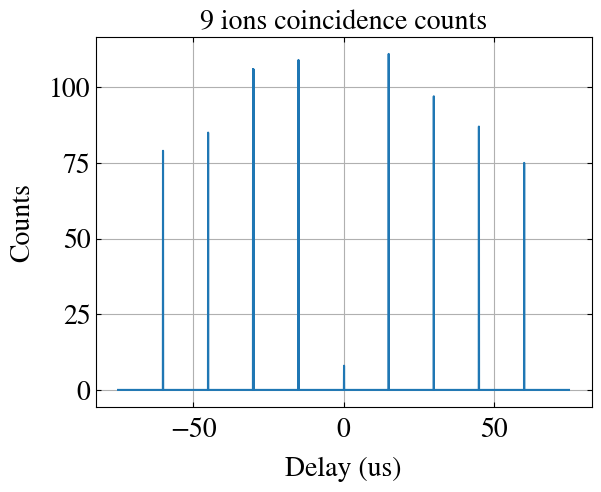

Date 2024-01-04, Time 11-14


In [ ]:
import numpy as np

# Example numpy array with peaks
data = data_sum

# Function to sum the values of nearby bins (5 bins) and set other bins to zero
def rearrange_peaks(data):
    # Length of the data array
    n = len(data)

    # New array to store the rearranged data
    new_data = np.zeros(n)

    # Iterate through the array
    for i in range(n):
        # Check if the current bin is a peak (max in its 5-bin neighborhood)
        if i == 0 or i == n-1:
            # Edge cases where the neighborhood is not 5 bins
            continue
        else:
            start = max(i-150, 0)
            end = min(i+150, n)
            if data[i] == max(data[start:end]):
                # Sum the values of the 5-bin neighborhood
                new_data[i] = np.sum(data[start:end])

    return new_data

# Apply the function to the data
rearranged_data = rearrange_peaks(data)
# rearranged_data = rearranged_data/np.max(rearranged_data)

# Plot the g(2) function
plt.plot(index, rearranged_data)
plt.title("9 ions coincidence counts", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)

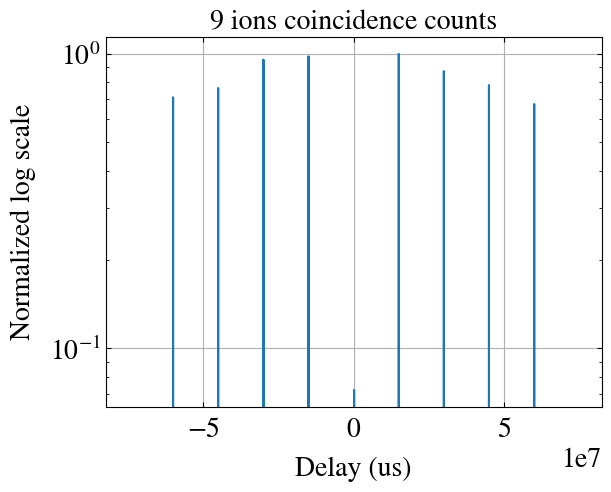

Date 2024-01-04, Time 12-45


In [38]:
# Plot the g(2) function
rearranged_data = rearranged_data/np.max(rearranged_data)
plt.plot(index, rearranged_data)
plt.title("9 ions coincidence counts", fontdict={'size':20})
plt.yscale('log')
plt.xlabel("Delay (us)")
plt.ylabel("Normalized log scale")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)